In [1]:
# Import necessary libraries

# Basic libraries for numerical operations, data manipulation, and visualization
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis
import seaborn as sns  # For statistical data visualization
import matplotlib.pyplot as plt  # For creating plots and figures
import warnings  # To handle warnings in the code
warnings.filterwarnings('ignore')  # Ignore warnings to reduce clutter

# Data Preprocessing and Feature Scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler  # For feature scaling (Standard and Min-Max scaling)

# Data Splitting and Model Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,cross_validate  # For splitting data, cross-validation, and hyperparameter tuning
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix  # For model evaluation and performance metrics

# Handling Imbalanced Datasets
from imblearn.over_sampling import SMOTE  # For handling imbalanced datasets
# Machine Learning Models (for classification)
from sklearn.linear_model import LogisticRegression  # Logistic Regression for binary classification
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron (Neural Network) for classification
from sklearn.svm import SVC  # Support Vector Machine classifier
from sklearn.ensemble import (
    RandomForestClassifier,  # Random Forest classifier
    GradientBoostingClassifier,  # Gradient Boosting classifier
    AdaBoostClassifier,  # AdaBoost classifier
    ExtraTreesClassifier,
    StackingClassifier,  # Stacking classifier
    VotingClassifier  # Voting classifier
)
from xgboost import XGBClassifier  # XGBoost classifier

# Model Interpretability (SHAP)
import shap

In [2]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


In [3]:
data = pd.read_csv("cleaned_data.csv")

In [5]:
data.head()

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol,Sex,GeneralHealth,...,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory,HadHeartAttack
0,0,0,7.0,11,22.7100,113,82,197,1,2,...,1,1,0,1,1,1,0,0,1,1
1,1,0,7.0,3,22.2400,106,77,190,1,4,...,0,1,0,1,0,0,0,2,1,0
2,0,0,6.0,11,34.1800,127,86,214,1,2,...,1,0,0,1,1,2,0,0,0,1
3,3,30,5.0,6,27.6938,114,72,202,0,4,...,0,0,1,1,1,1,0,2,1,0
4,7,0,8.0,11,23.2300,130,91,207,0,0,...,1,0,0,0,1,2,0,0,0,1


In [17]:
from sklearn.model_selection import train_test_split, cross_val_score,cross_validate
x = data.drop('HadHeartAttack',axis = 1)
y = data['HadHeartAttack']


In [18]:

# Split the data into training (80%) and temporary set (20%)
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

# Split the temporary set into validation (50% of temp, which is 10% of the total data) and testing (50% of temp, which is 10% of the total data)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

# Normalize or scale the data if necessary
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [19]:
# Print the shape of each dataset
print("Training set shape:", x_train.shape, y_train.shape)
print("Validation set shape:", x_val.shape, y_val.shape)
print("Test set shape:",x_test.shape, y_test.shape)

# Optionally preview the first few samples
print("\n--- Sample Training Data ---")
print(x_train[:3])
print("Labels:", y_train[:3])

print("\n--- Sample Validation Data ---")
print(x_val[:3])
print("Labels:", y_val[:3])

print("\n--- Sample Test Data ---")
print(x_test[:3])
print("Labels:", y_test[:3])


Training set shape: (21692, 37) (21692,)
Validation set shape: (2712, 37) (2712,)
Test set shape: (2712, 37) (2712,)

--- Sample Training Data ---
       PhysicalHealthDays  MentalHealthDays  SleepHours  AgeCategory    BMI  \
1287                    0                 0         6.0           10  23.73   
19179                   0                 0        11.0           12  22.86   
13764                  15                 0         8.0            9  40.45   

       SystolicBP  DiastolicBP  Cholesterol  Sex  GeneralHealth  ...  \
1287          134           88          206    1              4  ...   
19179         132           91          224    0              2  ...   
13764         141           88          228    1              2  ...   

       SmokerStatus  ChestScan  AlcoholDrinkers  HIVTesting  FluVaxLast12  \
1287              2          0                0           0             1   
19179             2          1                0           0             1   
13764           

In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Fit on y_train only
y_train = label_encoder.fit_transform(y_train)

# Transform y_val and y_test using the same encoder
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)


In [21]:
x_train

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol,Sex,GeneralHealth,...,SmokerStatus,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory
1287,0,0,6.0,10,23.7300,134,88,206,1,4,...,2,0,0,0,1,1,3,0,0,0
19179,0,0,11.0,12,22.8600,132,91,224,0,2,...,2,1,0,0,1,1,0,0,0,0
13764,15,0,8.0,9,40.4500,141,88,228,1,2,...,3,1,0,1,1,1,1,0,0,0
23404,0,0,8.0,6,31.9300,164,99,243,1,4,...,3,0,1,0,1,0,1,0,2,1
5099,0,0,8.0,4,36.9400,115,82,188,1,2,...,2,0,1,1,0,0,2,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,0,0,8.0,9,29.2700,159,92,245,1,2,...,3,1,1,0,1,1,2,0,0,1
5390,30,30,6.0,2,39.0500,141,95,225,0,1,...,0,1,0,0,0,1,2,0,0,1
860,7,0,7.0,5,34.5779,129,87,192,0,1,...,3,1,1,0,0,0,3,0,2,0
15795,3,5,9.0,9,27.4400,118,76,202,0,1,...,3,1,0,0,0,1,0,0,2,1


In [22]:
x_test

,PhysicalHealthDays,MentalHealthDays,SleepHours,AgeCategory,BMI,SystolicBP,DiastolicBP,Cholesterol,Sex,GeneralHealth,...,SmokerStatus,ChestScan,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,PrematureFamilyHistory
26697,1,0,6.0,7,37.59,148,91,237,0,2,...,3,0,0,1,1,1,1,0,2,0
3244,7,0,8.0,8,31.78,115,79,213,1,2,...,2,1,0,1,0,1,3,0,0,0
18285,2,1,8.0,3,26.57,102,60,197,0,4,...,3,0,1,1,1,0,1,0,2,1
1383,0,0,5.0,8,25.82,142,88,229,0,2,...,2,0,0,0,0,0,1,0,2,0
12896,0,0,8.0,2,34.77,125,82,182,0,2,...,3,0,0,0,0,0,3,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23046,0,0,8.0,12,22.24,110,70,170,1,0,...,2,1,1,0,1,1,0,0,0,0
23555,21,21,4.0,5,19.08,136,88,212,1,1,...,1,1,0,1,0,1,1,0,0,0
16174,29,15,10.0,8,36.92,152,89,235,1,1,...,3,1,1,0,0,0,2,0,0,1
22218,0,0,6.0,11,29.99,138,93,221,1,2,...,2,1,1,0,0,0,0,0,0,0


In [23]:
# Encode categorical variables
data_encoded = data.copy()
for col in data_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'XGB': XGBClassifier(),
    'Neural Network': MLPClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Extra Tree': ExtraTreesClassifier()
}


param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    'AdaBoost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 1]
    },
    'XGB': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    'Neural Network': {
        'hidden_layer_sizes': [(100,), (50, 50)],
        'activation': ['relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01]
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    },
    'Extra Tree': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    }
}


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
# 4. Define samplers
samplers = {
    'Random undersampling': RandomUnderSampler(random_state=42),
    'Random oversampling': RandomOverSampler(random_state=42),
    'SMOTE sampling': SMOTE(random_state=42),
    'Cost-sensitive learning': None
}

# 5. Prepare plots and results
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()
summary_results = []

# 6. Train and evaluate models
for i, (title, sampler) in enumerate(samplers.items()):
    ax = axs[i]
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(x_train_scaled, y_train)
    else:
        X_resampled, y_resampled = x_train_scaled, y_train

    ax.set_title(f'({chr(97+i)}) {title}')
    for name, model in models.items():
        clf = model
        clf = clf.set_params(class_weight='balanced') if title == 'Cost-sensitive learning' and hasattr(clf, 'class_weight') else clf
        if title == 'Cost-sensitive learning' and isinstance(clf, XGBClassifier):
            class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
            clf.set_params(scale_pos_weight=class_weights[1] / class_weights[0])

        clf.fit(X_resampled, y_resampled)
        y_pred = clf.predict(x_test_scaled)
        y_proba = clf.predict_proba(x_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(x_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

        summary_results.append({
            'Sampling': title,
            'Model': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1 Score': f1,
            'ROC AUC': roc_auc
        })

    ax.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.suptitle('ROC curve for different sampling methods', fontsize=16, y=1.03)
plt.subplots_adjust(top=0.92)
plt.savefig('roc.png')
plt.show()

# 7. Create summary DataFrame
performance_df = pd.DataFrame(summary_results)
performance_df.head(20)


In [31]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Result list
results = []

# Evaluate each model with each sampler
for sampler_name, sampler in samplers.items():
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(x_train, y_train)
    else:
        X_resampled, y_resampled = x_train, y_train

    for model_name, model in models.items():
        model.fit(X_resampled, y_resampled)
        y_pred = model.predict(x_test)
        acc = accuracy_score(y_test, y_pred)

        results.append({
            'Sampler': sampler_name,
            'Model': model_name,
            'Accuracy': round(acc, 4)
        })

# Create and display results table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Print the table
print(results_df)

# Save to CSV
results_df.to_csv("model_sampler_accuracy_table.csv", index=False)
print("\n✅ Results table saved to 'model_sampler_accuracy_table.csv'")


                    Sampler                Model  Accuracy
0   Cost-sensitive learning    Gradient Boosting    0.7865
1            SMOTE sampling             AdaBoost    0.7843
2       Random oversampling        Random Forest    0.7839
3       Random oversampling             AdaBoost    0.7836
4       Random oversampling    Gradient Boosting    0.7836
5      Random undersampling    Gradient Boosting    0.7832
6            SMOTE sampling    Gradient Boosting    0.7828
7      Random undersampling             AdaBoost    0.7817
8            SMOTE sampling        Random Forest    0.7810
9   Cost-sensitive learning             AdaBoost    0.7806
10      Random oversampling       Neural Network    0.7788
11     Random undersampling        Random Forest    0.7784
12  Cost-sensitive learning        Random Forest    0.7765
13     Random undersampling           Extra Tree    0.7754
14           SMOTE sampling       Neural Network    0.7751
15  Cost-sensitive learning           Extra Tree    0.77

In [18]:
# Save performance results
performance_df.to_csv("model_performance_results.csv", index=False)
performance_df.to_excel("model_performance_results.xlsx", index=False)

print("\n✅ Performance results saved as 'model_performance_results.csv' and 'model_performance_results.xlsx'")



✅ Performance results saved as 'model_performance_results.csv' and 'model_performance_results.xlsx'


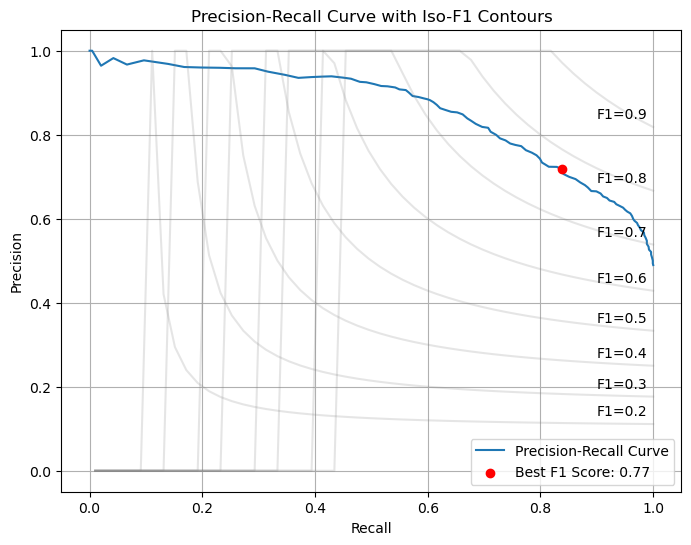

In [39]:
from sklearn.metrics import precision_recall_curve

y_scores = model.predict_proba(x_val)[:, 1]
import numpy as np

f1_scores = 2 * precision * recall / (precision + recall + 1e-8)  # Adding a small value to avoid division by zero

precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]
best_precision = precision[best_index]
best_recall = recall[best_index]
# Plot the precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.scatter(best_recall, best_precision, color='red',
            label=f'Best F1 Score: {best_f1:.2f}', zorder=5)

# Overlay iso-F1 score contours
f_scores = np.linspace(0.2, 0.9, num=8)
for f_score in f_scores:
    x = np.linspace(0.01, 1)
    y = (f_score * x) / (2 * x - f_score + 1e-8)
    y = np.clip(y, 0, 1)
    plt.plot(x, y, color='gray', alpha=0.2)
    plt.annotate(f'F1={f_score:.1f}', xy=(0.9, y[-1] + 0.02))

# Finalize the plot
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Iso-F1 Contours')
plt.legend()
plt.savefig('pr')
plt.grid(True)
plt.show()

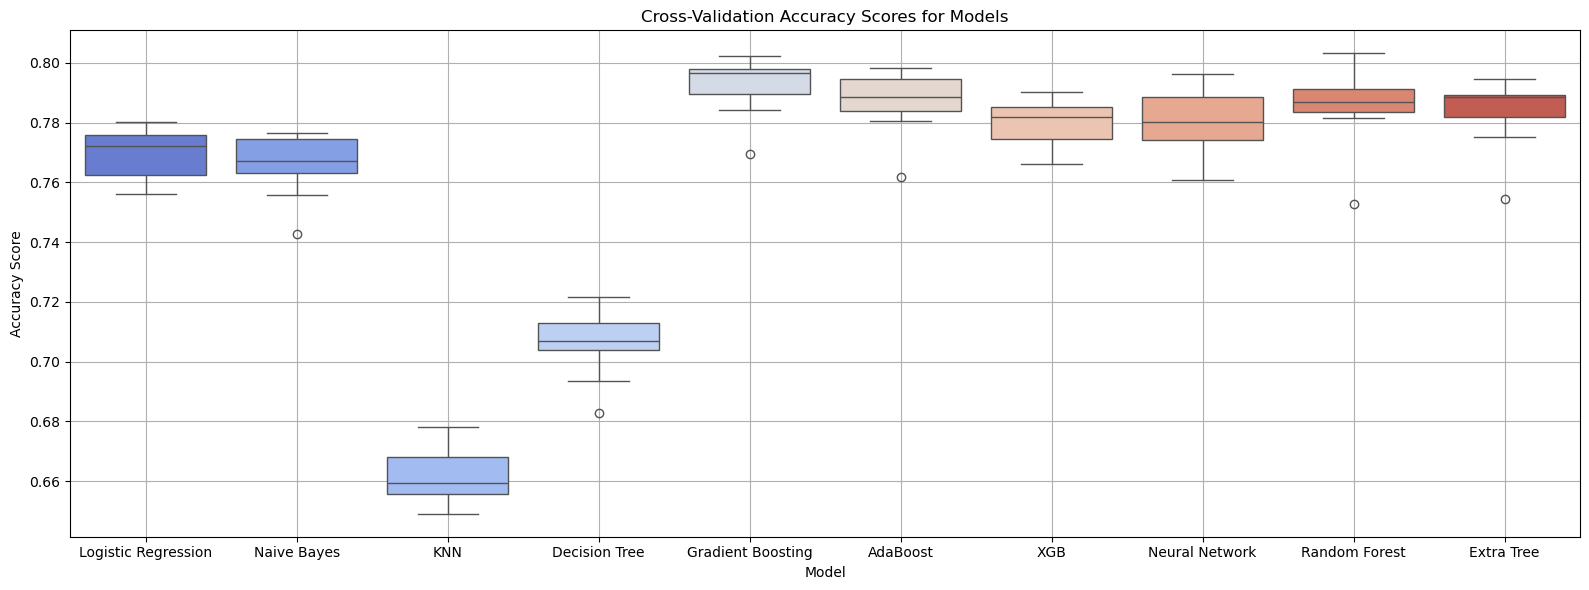

In [40]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'models' is a dictionary of model names and instances
results = {}
for name, model in models.items():
    # Perform 5-fold cross-validation for each model
    cv_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='accuracy')
    results[name] = cv_scores

# Convert results to a list of values for plotting
data = []
for name, scores in results.items():
    for score in scores:
        data.append([name, score])

# Create DataFrame for Seaborn plotting
import pandas as pd
df = pd.DataFrame(data, columns=['Model', 'Accuracy'])

# Plotting the box plot
plt.figure(figsize=(16, 6))
sns.boxplot(x='Model', y='Accuracy', data=df,palette='coolwarm')
plt.title('Cross-Validation Accuracy Scores for Models')
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.grid(True)
plt.tight_layout()
plt.savefig('cross')
plt.show()


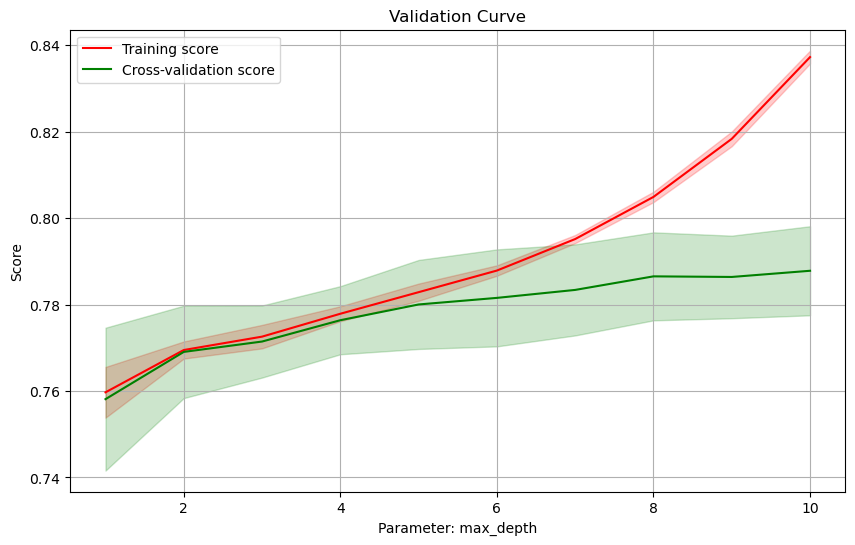

In [47]:
from sklearn.model_selection import validation_curve

def plot_validation_curve(model, param_name, param_range, x, y, cv=None, scoring='accuracy'):
    train_scores, test_scores = validation_curve(model, x, y, param_name=param_name, param_range=param_range, cv=cv, scoring=scoring)

    # Calculate mean and std for training and validation scores
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_scores_mean, label="Training score", color="r")
    plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="g")

    # Fill std deviation
    plt.fill_between(param_range, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.2, color="r")
    plt.fill_between(param_range, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.2, color="g")

    plt.title("Validation Curve")
    plt.xlabel(f'Parameter: {param_name}')
    plt.ylabel("Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.savefig('validation')
    plt.show()

# Example for one model
param_range = np.arange(1, 11)
plot_validation_curve(models['Random Forest'], param_name="max_depth", param_range=param_range, x=x_train, y=y_train, cv=10)

In [43]:
# Perform cross-validation with multiple scoring metrics
cv_results = cross_validate(RandomForestClassifier(), x_train, y_train, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1'])
# Print the cross-validation results
print("Cross-validated Accuracy: {:.2f}".format(cv_results['test_accuracy'].mean()))
print("Cross-validated Precision: {:.2f}".format(cv_results['test_precision'].mean()))
print("Cross-validated Recall: {:.2f}".format(cv_results['test_recall'].mean()))
print("Cross-validated F1 Score: {:.2f}".format(cv_results['test_f1'].mean()))

Cross-validated Accuracy: 0.79
Cross-validated Precision: 0.80
Cross-validated Recall: 0.76
Cross-validated F1 Score: 0.78


In [44]:
cv_results = np.round(pd.DataFrame(cv_results),2)
cv_results.iloc[:,2:]

,test_accuracy,test_precision,test_recall,test_f1
0,0.79,0.81,0.76,0.78
1,0.77,0.80,0.73,0.76
2,0.79,0.79,0.78,0.79
3,0.79,0.80,0.76,0.78
4,0.79,0.80,0.76,0.78


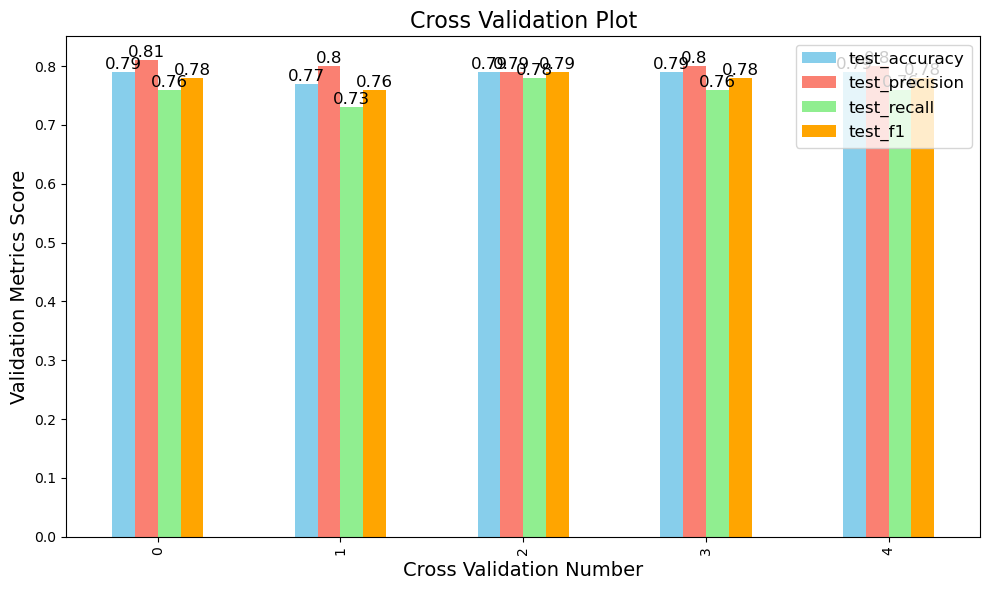

In [48]:
import matplotlib.pyplot as plt

# Define a list of colors for each bar
bar_colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'plum']  # Add more colors as needed

# Plot the bar chart with specified colors
ax = cv_results.iloc[:, 2:].plot.bar(
    figsize=(10, 6),
    color=bar_colors  # Assign different colors to each bar
)

# Add labels to each bar with specified font size and color
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=12, color='black')

# Customize the legend
plt.legend(loc='upper right', fontsize=12)

# Set axis labels and title with specified font sizes
plt.xlabel('Cross Validation Number', fontsize=14)
plt.ylabel('Validation Metrics Score', fontsize=14)
plt.title('Cross Validation Plot', fontsize=16)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('cv')
plt.show()


In [49]:
import pickle
# Save the model
with open("cvds_model.pkl", "wb") as file:
    pickle.dump(model, file)
